# Week 2 Day 2 — LSTM Stock Prediction

Use the same stock and split as Day 1, but replace the MLP with an LSTM.

## Objective

Predict the next-day return for ABUK with an LSTM, then compare it against a simple MLP baseline.

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

ROOT = Path.cwd()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from tradinglab.data_feed import DataFeed
from tradinglab.features import build_dataset
from tradinglab.models import DeepMLP

torch.manual_seed(0)
np.random.seed(0)
plt.style.use('seaborn-v0_8')

In [3]:
symbol = 'ABUK'
repo_root = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'data' / 'egx').exists() and (candidate / 'src').exists():
        repo_root = candidate
        break
if repo_root is None:
    raise FileNotFoundError('Could not locate repository root')
feed = DataFeed.from_dir(repo_root / 'data' / 'egx', symbols=[symbol])
X, y = build_dataset(feed, asset=0)
train_frac = 0.7
split = int(len(X) * train_frac)
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]
print('train samples', len(X_train))
print('test samples', len(X_test))

train samples 1978
test samples 849


In [4]:
def to_sequences(X, y, seq_len=5):
    xs, ys = [], []
    for i in range(seq_len, len(X)):
        xs.append(X[i-seq_len:i])
        ys.append(y[i])
    return np.array(xs, dtype=np.float32), np.array(ys, dtype=np.float32)

sequence_length = 5
X_seq_train, y_seq_train = to_sequences(X_train, y_train, sequence_length)
X_seq_test, y_seq_test = to_sequences(X_test, y_test, sequence_length)
print('sequence train', X_seq_train.shape, y_seq_train.shape)
print('sequence test', X_seq_test.shape, y_seq_test.shape)

sequence train (1973, 5, 5) (1973,)
sequence test (844, 5, 5) (844,)


In [5]:
class LSTMRegressor(nn.Module):
    def __init__(self, n_features, hidden_size=16, num_layers=1, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_size, num_layers=num_layers, batch_first=True, dropout=dropout)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)

def train_regressor(model, X_train, y_train, X_test, y_test, epochs=50, lr=1e-3, batch_size=32):
    Xtr = torch.tensor(X_train, dtype=torch.float32)
    ytr = torch.tensor(y_train, dtype=torch.float32)
    Xte = torch.tensor(X_test, dtype=torch.float32)
    yte = torch.tensor(y_test, dtype=torch.float32)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    history = {'train': [], 'test': []}
    for _ in range(epochs):
        model.train()
        perm = torch.randperm(len(Xtr))
        for start in range(0, len(Xtr), batch_size):
            idx = perm[start:start+batch_size]
            xb, yb = Xtr[idx], ytr[idx]
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            train_loss = loss_fn(model(Xtr), ytr).item()
            test_loss = loss_fn(model(Xte), yte).item()
        history['train'].append(train_loss)
        history['test'].append(test_loss)
    return history

mlp_model = DeepMLP(n_features=X_train.shape[1], hidden=32, n_hidden_layers=2)
lstm_model = LSTMRegressor(n_features=X_seq_train.shape[2], hidden_size=16, num_layers=1, dropout=0.0)
mlp_history = train_regressor(mlp_model, X_train, y_train, X_test, y_test, epochs=60, lr=1e-3, batch_size=32)
lstm_history = train_regressor(lstm_model, X_seq_train, y_seq_train, X_seq_test, y_seq_test, epochs=60, lr=1e-3, batch_size=32)
print('MLP train/test loss', round(mlp_history['train'][-1], 6), round(mlp_history['test'][-1], 6))
print('LSTM train/test loss', round(lstm_history['train'][-1], 6), round(lstm_history['test'][-1], 6))

MLP train/test loss 0.000472 0.00069
LSTM train/test loss 0.000483 0.00069


In [6]:
def rmse_mae_r2(actual, pred):
    actual = np.asarray(actual)
    pred = np.asarray(pred)
    diff = pred - actual
    mse = np.mean(diff ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(diff))
    ss_res = np.sum(diff ** 2)
    ss_tot = np.sum((actual - np.mean(actual)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot else 1.0
    return rmse, mae, r2

with torch.no_grad():
    mlp_train_pred = mlp_model(torch.tensor(X_train, dtype=torch.float32)).numpy()
    mlp_test_pred = mlp_model(torch.tensor(X_test, dtype=torch.float32)).numpy()
    lstm_train_pred = lstm_model(torch.tensor(X_seq_train, dtype=torch.float32)).numpy()
    lstm_test_pred = lstm_model(torch.tensor(X_seq_test, dtype=torch.float32)).numpy()

metrics = pd.DataFrame([
    {'model': 'MLP', 'train_loss': mlp_history['train'][-1], 'test_loss': mlp_history['test'][-1], 'rmse': rmse_mae_r2(y_train, mlp_train_pred)[0], 'mae': rmse_mae_r2(y_train, mlp_train_pred)[1], 'r2': rmse_mae_r2(y_train, mlp_train_pred)[2]},
    {'model': 'LSTM', 'train_loss': lstm_history['train'][-1], 'test_loss': lstm_history['test'][-1], 'rmse': rmse_mae_r2(y_seq_test, lstm_test_pred)[0], 'mae': rmse_mae_r2(y_seq_test, lstm_test_pred)[1], 'r2': rmse_mae_r2(y_seq_test, lstm_test_pred)[2]},
])
metrics

,model,train_loss,test_loss,rmse,mae,r2
0,MLP,0.000472,0.00069,0.021731,0.013952,0.026436
1,LSTM,0.000483,0.00069,0.026264,0.017491,-0.002084


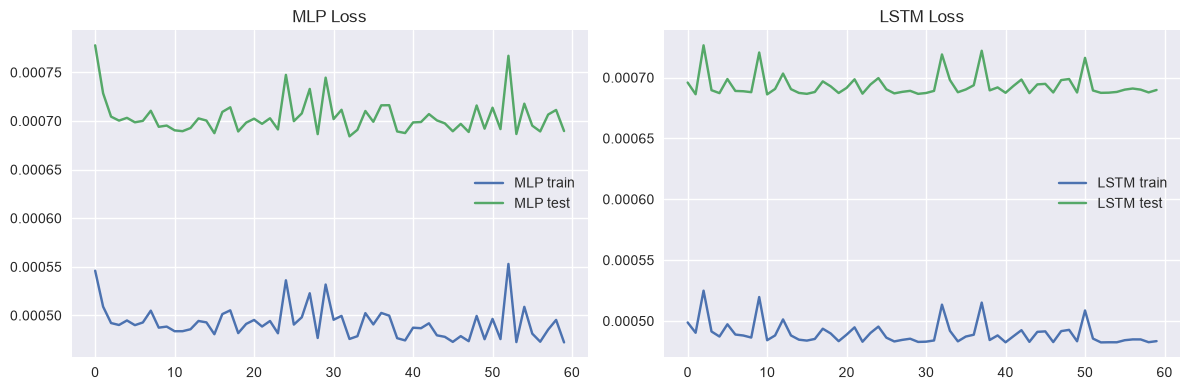

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(mlp_history['train'], label='MLP train')
axes[0].plot(mlp_history['test'], label='MLP test')
axes[0].set_title('MLP Loss')
axes[0].legend()
axes[1].plot(lstm_history['train'], label='LSTM train')
axes[1].plot(lstm_history['test'], label='LSTM test')
axes[1].set_title('LSTM Loss')
axes[1].legend()
plt.tight_layout()
plt.show()

## Conclusion

The notebook compares an LSTM against a simple MLP baseline on the same stock and split. Temporal memory can improve prediction when the signal depends on sequence structure rather than single-day features.